In [2]:
import pdblp

import pandas as pd
import numpy as np
import pytz

import seaborn as sns
import matplotlib.pyplot as plt

from xbbg import blp
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

from pandas.tseries.offsets import DateOffset

from matplotlib.ticker import MaxNLocator

In [3]:
def getDailySpot(ticker, days):
    start_date = (datetime.today() - timedelta(days=365*days)).strftime('%Y-%m-%d')
    end_date = datetime.today().strftime('%Y-%m-%d')
    ticker_IV = f"{ticker} Curncy"
    data_IV = blp.bdh(
        tickers=ticker_IV,
        flds = 'last_price',
        start_date=start_date,
        end_date=end_date)
    data_IV.columns = data_IV.columns.droplevel(1)
    return data_IV

In [4]:
ticker = 'EURUSDVON'
days = 1
getDailySpot(ticker, days)

,EURUSDVON Curncy
2024-11-18,7.6075
2024-11-19,7.5400
2024-11-20,8.9025
2024-11-21,11.2875
2024-11-22,6.6525
...,...
2025-11-12,5.6500
2025-11-13,6.3300
2025-11-14,3.7100
2025-11-17,5.2575


In [ ]:
def Daily_GetTopCCYs(currency_pairs, years):
    df_ccy = {}
    start_date = (datetime.today() - timedelta(days= years * 356)).strftime('%Y-%m-%d')
    end_date = datetime.today().strftime('%Y-%m-%d')

    for ticker in currency_pairs:
        data_ccy = blp.bdh(
            tickers=f"{ticker}" ,
            flds=["PX_LAST"],  # Adjust fields as needed
            start_date=start_date,
            end_date=end_date,
            Per="D"  # Daily data
        )
        data_ccy.columns = [ticker]
        df_ccy[ticker] = data_ccy
    df_ccyAll = pd.concat(df_ccy, axis=1)
    df_ccyAll.columns = df_ccyAll.columns.droplevel(0) if isinstance(df_ccyAll.columns, pd.MultiIndex) else df_ccyAll.columns
    df_ccyAll = df_ccyAll.sort_index(ascending=True)


    return df_ccyAll

In [ ]:
def getDailySpot(ticker, days):
    start_date = (datetime.today() - timedelta(days=days)).strftime('%Y-%m-%d')
    end_date = datetime.today().strftime('%Y-%m-%d')
    ticker_IV = f"{ticker} BGN Curncy"
    flds=['high', 'low', 'last_price', 'open']
    data_IV = blp.bdh(
        tickers=ticker_IV,
        flds = flds,
        start_date=start_date,
        end_date=end_date)
    data_IV.columns = ["high", "low", "close", "open"]
    return data_IV


def getintradayCCY(ticker, days, interv):
    con = pdblp.BCon(debug=False, port=8194, timeout=5000)
    con.start()
    # State Correct time zone
    eastern = pytz.timezone("US/Eastern")
    end_time_et = eastern.localize(datetime.now())
    start_time_et = end_time_et - timedelta(days=365*days)
    # Convert to GMT (UTC)
    end_time_gmt = end_time_et.astimezone(pytz.utc)
    start_time_gmt = start_time_et.astimezone(pytz.utc)
    # Pull data 
    df = con.bdib(
            ticker=f"{ticker} Curncy",     
            start_datetime=start_time_gmt,    
            end_datetime=end_time_gmt,        
            event_type="TRADE",           
            interval= interv)
    df.index = df.index.tz_localize('UTC').tz_convert('US/Eastern')
    df = df.reset_index()
    df['date'] = df['time'].dt.date  # Extract the date
    df['time_close'] = df['time'].dt.time  # Extract the time
    df = df.drop(columns=['time']) 
    df = df[['date', 'time_close'] + [col for col in df.columns if col not in ['date', 'time_close']]]
    df['datetime'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['time_close'].astype(str))
    # Set 'datetime' as the index
    df.set_index('datetime', inplace=True)
    df.drop(columns=['date', 'time_close'], inplace=True)
    return df

In [10]:
ticker = 'EURUSD'
days = 1
interval = 10

df_ID = getintradayCCY(ticker, days, interval)
df_ID

,open,high,low,close,volume,numEvents
datetime,,,,,,
2025-05-05 17:00:00,1.1315,1.1317,1.1313,1.1315,0,5473
2025-05-05 17:10:00,1.1315,1.1318,1.1315,1.1317,0,5437
2025-05-05 17:20:00,1.1317,1.1319,1.1317,1.1318,0,5423
2025-05-05 17:30:00,1.1318,1.1319,1.1316,1.1317,0,5317
2025-05-05 17:40:00,1.1317,1.1319,1.1317,1.1319,0,5419
...,...,...,...,...,...,...
2025-11-18 11:00:00,1.1582,1.1584,1.1576,1.1577,0,14417
2025-11-18 11:10:00,1.1577,1.1579,1.1573,1.1578,0,12766
2025-11-18 11:20:00,1.1578,1.1578,1.1574,1.1574,0,11611


In [ ]:
# -------------------------------------------- IntraDay ----------------------------------- 

In [4]:
# Get IntraDay rolling Close to Close Realized Vol
def getIntraDay_RollingC2CVol(df, interval, window):
    F = 1440/interval

    logRetrunC2C = np.log(df['close'] / df['close'].shift(1)).dropna()

    rollingVolC2C = logRetrunC2C.rolling(window=window).apply(
            lambda x: np.sqrt((np.sum(x ** 2) * F * 252) / len(x)), raw= True
    )
    
    return rollingVolC2C * 100 



# Get IntraDay rolling GK Realized Vol
def getIntraDay_RollingGKVol(df, interval, window):
    F = 1440 / interval


    logReturn_HL = np.log(df['high'] / df['low']).dropna()  # High-Low log return
    logReturn_CO = np.log(df['close'] / df['open']).dropna()  # Close-Open log return

    rollingVol = (
        logReturn_HL.rolling(window=window).apply(lambda x: np.sum(x ** 2) / 2, raw=True) - 
        (2 * np.log(2) - 1) * logReturn_CO.rolling(window=window).apply(lambda x: np.sum(x ** 2), raw=True)
    )

    rollingVol = rollingVol.apply(lambda x: np.sqrt(np.abs(F * 252 * x / window)) * 100 )

    return rollingVol

# -------------------------------------------------------------------------------------------------------------------------------------

# Get the IntraDay Variance ratio of specific Tenor      (GK / C2C)
def getIntraDay_VR_tenor(ticker, days, interval, window, tenor):

    df_ID = getintradayCCY(ticker, days, interval)


    df_ID['IDRolHV_C2C'] = getIntraDay_RollingC2CVol(df_ID, interval, window)
    df_ID['IDRollHV_GK'] = getIntraDay_RollingGKVol(df_ID, interval, window)

    df_ID["GK_C2C_VR"] = df_ID["IDRollHV_GK"] / df_ID["IDRolHV_C2C"]

    df_ID.index = pd.to_datetime(df_ID.index)
    df_ID = df_ID.sort_index()
    today = datetime.today()

    date_ranges = {
        "1W": today - timedelta(weeks=1),
        "2W": today - timedelta(weeks=2),
        "3W": today - timedelta(weeks=3),
        "1M": today - relativedelta(months=1),  
        "6W": today - timedelta(weeks=6),
        "2M": today - relativedelta(months=2),  
        "3M": today - relativedelta(months=3), 
        "4M": today - relativedelta(months=4),
        "5M": today - relativedelta(months=5),
        "6M": today - relativedelta(months=6)
    }

    df_splits = {}

    for label, date_threshold in date_ranges.items():
        if label == tenor:
            df_filtered = df_ID[df_ID.index >= date_ranges[tenor]].copy()

    return df_filtered['GK_C2C_VR'] 



In [5]:

# Plotting Variance Ratio and Spot comparison
def plotIntraDay_GK_C2C_VR(df_ID, interval, window, interestPeriod):

    df_ID['df_IDRoll_HVC2C'] = getIntraDay_RollingC2CVol(df_ID, interval, window)
    df_ID['df_IDRoll_HVGK'] = getIntraDay_RollingGKVol(df_ID, interval, window)

    df_ID = df_ID.tail(interestPeriod)

    # Ensure 'datetime' index exists for proper plotting
    if "datetime" in df_ID.index.names:
        df_ID = df_ID.reset_index()

    # Convert datetime column if necessary
    df_ID["datetime"] = pd.to_datetime(df_ID["datetime"])

    # Compute the GK-to-C2C volatility ratio
    df_ID["GK_to_C2C_Ratio"] = df_ID["df_IDRoll_HVGK"] / df_ID["df_IDRoll_HVC2C"]

    # **Use numerical index for plotting**
    df_ID = df_ID.reset_index(drop=True)  # Reset index to 0, 1, 2, ...
    df_ID["Index"] = df_ID.index + 1  # Start from 1 instead of 0

    # Select major tick positions & corresponding dates
    num_ticks = 10  # Adjust this for more or fewer date labels
    tick_positions = df_ID["Index"][::len(df_ID) // num_ticks].tolist()
    tick_labels = df_ID["datetime"][::len(df_ID) // num_ticks].dt.strftime("%Y-%m-%d %H:%M").tolist()

    # Create the plot
    fig, ax1 = plt.subplots(figsize=(20, 10))

    # Primary Y-axis (GK-to-C2C Ratio)
    ax1.set_xlabel("Date (Labeled at Intervals)")
    ax1.set_ylabel("GK-to-C2C Vol Ratio", color="blue")
    ax1.plot(df_ID["Index"], df_ID["GK_to_C2C_Ratio"], label="GK/C2C Vol Ratio", color="blue", alpha=0.7)
    ax1.tick_params(axis="y", labelcolor="blue")
    ax1.legend(loc="upper left")
    ax1.grid()

    # **Set custom x-axis ticks to display dates**
    ax1.set_xticks(tick_positions)
    ax1.set_xticklabels(tick_labels, rotation=45, ha="right")  # Rotate for better readability

    # Secondary Y-axis (Spot Prices)
    ax2 = ax1.twinx()
    ax2.set_ylabel("Spot Price", color="black")
    ax2.plot(df_ID["Index"], df_ID["close"], label="Spot Price", color="black", linewidth=1.2, alpha=0.8)
    ax2.tick_params(axis="y", labelcolor="black")
    ax2.legend(loc="upper right")

    # **Ensure integer Y-axis values**
    ax1.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Title
    plt.title("GK-to-C2C Volatility Ratio vs. Spot Price (Indexed with Date Labels)")
    plt.show()



# Plotting Distributions of of VR -- 1W-6M
def plotIntraDay_VR_AllDist(ticker, days, interval, window):


    df_ID = getintradayCCY(ticker, days, interval)


    df_ID['IDRolHV_C2C'] = getIntraDay_RollingC2CVol(df_ID, interval, window)
    df_ID['IDRollHV_GK'] = getIntraDay_RollingGKVol(df_ID, interval, window)

    df_ID["GK_C2C_VR"] = df_ID["IDRollHV_GK"] / df_ID["IDRolHV_C2C"]


    window_sizes = {
        "1W": 5 * window,
        "2W": 10 * window,
        "3W": 15 * window,
        "1M": 20 * window,
        "6W": 30 *window,
        "2M": 40 * window,
        "3M": 40 * window,
        "4M": 40 * window,
        "5M": 40 * window,
        "6M": 120 * window,

    }

    df_splits = {}


    for label, window in window_sizes.items():
        df_splits[label] = df_ID.tail(window).copy()  


    df_1W = df_splits["1W"][['GK_C2C_VR']]
    df_2W = df_splits["2W"][['GK_C2C_VR']]
    df_3W = df_splits["3W"][['GK_C2C_VR']]
    df_1M = df_splits["1M"][['GK_C2C_VR']]
    df_6W = df_splits["6W"][['GK_C2C_VR']]
    df_2M = df_splits["2M"][['GK_C2C_VR']]
    df_3M = df_splits["3M"][['GK_C2C_VR']]
    df_4M = df_splits["4M"][['GK_C2C_VR']]
    df_5M = df_splits["5M"][['GK_C2C_VR']]
    df_6M = df_splits["6M"][['GK_C2C_VR']]




    # Define list of dataframes and their labels
    df_list = [df_1W, df_2W, df_3W, df_1M, df_6W, df_2M, df_3M, df_4M, df_5M, df_6M]
    labels = ["1W", "2W", "3W", "1M", "6W", "2M", "3M", "4M", "5M", "6M"]

    # Set up a 3-column grid layout
    rows = (len(df_list) + 2) // 3  # Ensures correct row count
    fig, axes = plt.subplots(rows, 3, figsize=(15, 10))  # Adjust figure size
    axes = axes.flatten()  # Flatten for easy iteration

    # Loop through dataframes and plot distributions
    for i, (df, label) in enumerate(zip(df_list, labels)):
        data = df["GK_C2C_VR"].dropna()
        
        # Calculate statistics
        mean = np.mean(data)
        std = np.std(data)
        
        # Plot histogram with KDE
        sns.histplot(data, bins=50, kde=True, ax=axes[i], color='blue', alpha=0.6)
        
        # Plot vertical lines for mean and ±2 standard deviations
        axes[i].axvline(mean, color='red', linestyle='dashed', linewidth=2, label="Mean")
        axes[i].axvline(mean - 1.5 * std, color='green', linestyle='dotted', linewidth=2, label="-1.5 Std")
        axes[i].axvline(mean + 1.5 * std, color='green', linestyle='dotted', linewidth=2, label="+1.5 Std")

        # Titles and labels
        axes[i].set_title(f"{ticker} Variance Ratio - {label}")
        axes[i].set_xlabel("GK_C2C_VR")
        axes[i].set_ylabel("Frequency")
        axes[i].legend(loc="upper right")  # Show legend

    # Remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()  # Optimize layout
    return plt.show()

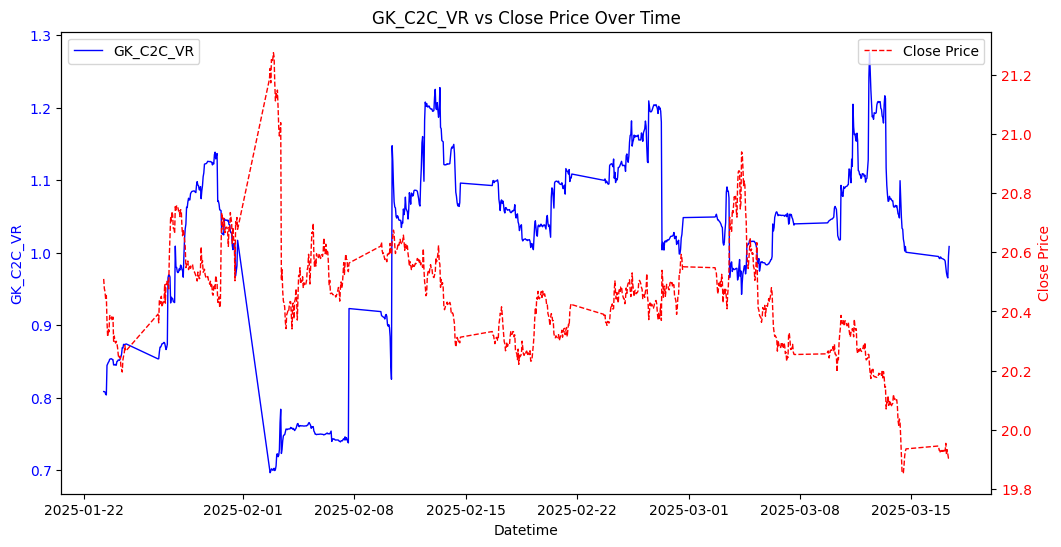

In [8]:
ticker = 'USDMXN'
days = 60
interval = 60
window = int(5 * (1440 / 60))

df_ID = getintradayCCY(ticker, days, interval)



df_ID['IDRolHV_C2C'] = getIntraDay_RollingC2CVol(df_ID, interval, window)
df_ID['IDRollHV_GK'] = getIntraDay_RollingGKVol(df_ID, interval, window)

df_ID["GK_C2C_VR"] = (df_ID["IDRollHV_GK"] / df_ID["IDRolHV_C2C"])

df_ID = df_ID.dropna()




# Create figure and primary y-axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot GK_C2C_VR on primary y-axis (left)
ax1.plot(df_ID.index, df_ID['GK_C2C_VR'], color='blue', label='GK_C2C_VR', linewidth=1)
ax1.set_xlabel("Datetime")
ax1.set_ylabel("GK_C2C_VR", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title("GK_C2C_VR vs Close Price Over Time")

# Create secondary y-axis (right)
ax2 = ax1.twinx()
ax2.plot(df_ID.index, df_ID['close'], color='red', label='Close Price', linewidth=1, linestyle="dashed")
ax2.set_ylabel("Close Price", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add Legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.show()

In [ ]:
# ----------- GK HVol / C2C HVol -------------

In [1]:


1440/60


24.0

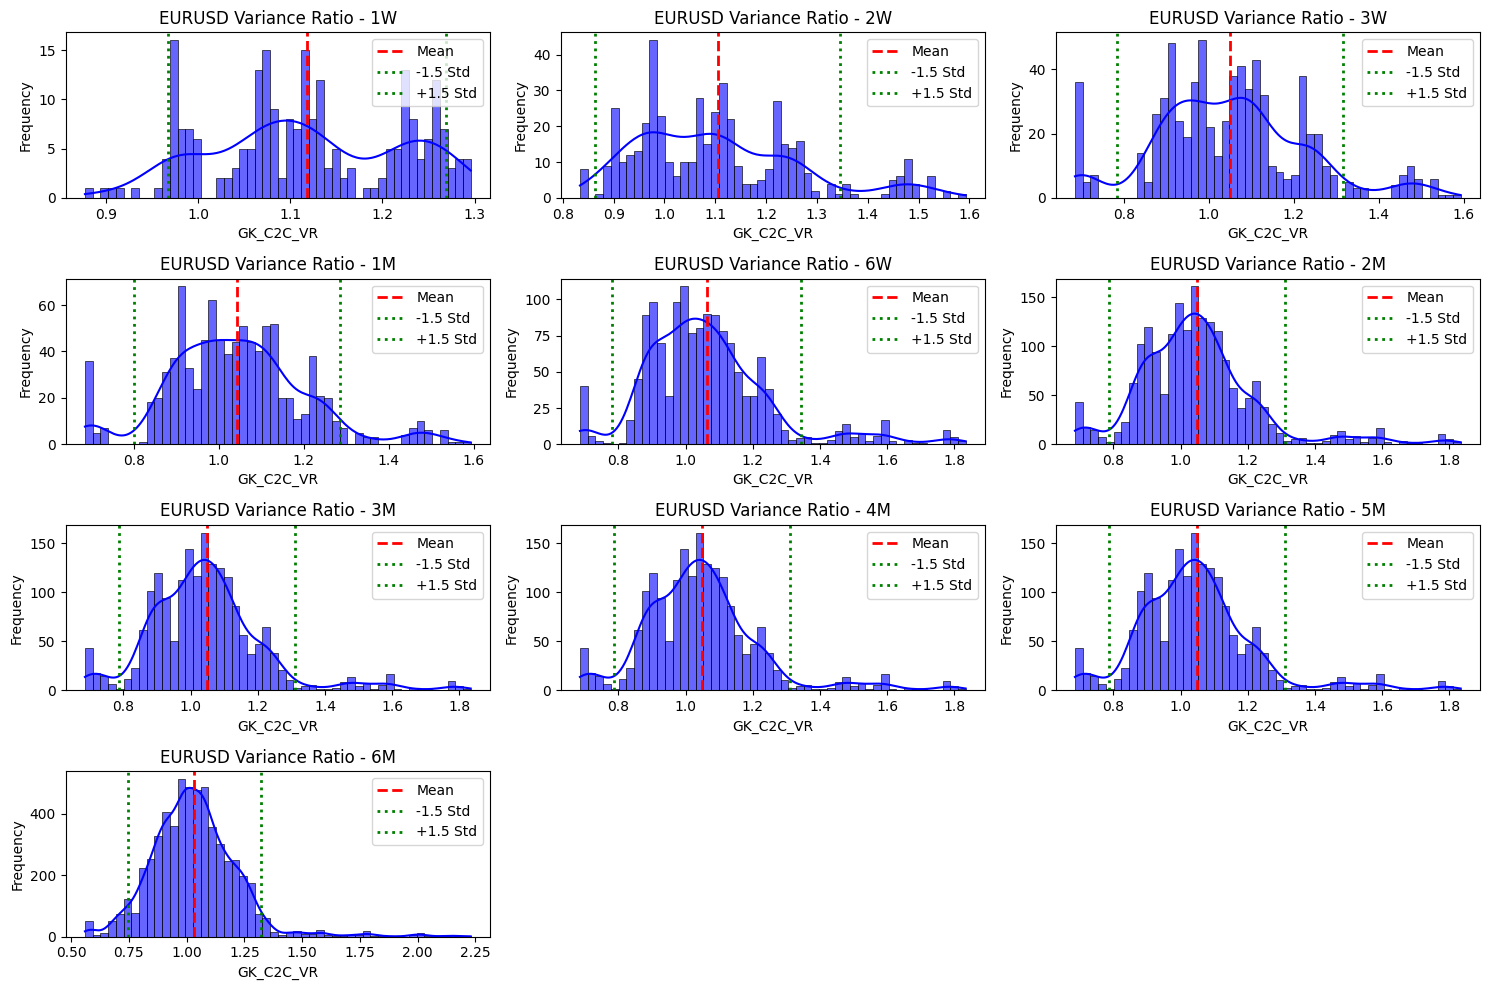

In [57]:

ticker = 'EURUSD'
days = 365
interval = 30
window = 48   # Amount of increments to look back (48 Window = 1 day lookback sample)

plotIntraDay_VR_AllDist(ticker, days, interval, window)